In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -q peft accelerate tensorboard

In [3]:
import os
import xml.etree.ElementTree as ET
import json
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPProcessor, CLIPModel
from peft import LoraConfig, get_peft_model
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import random

# 设置数据集路径（Kaggle挂载的数据集位置）
DATA_ROOT = "/kaggle/input/datasets/dongly/shipdataset/SeaShips(7000)"  # 注意检查这个路径是否正确，可能需要调整
print("数据集目录内容：", os.listdir(DATA_ROOT))

# 确认子文件夹存在
assert 'JPEGImages' in os.listdir(DATA_ROOT), "JPEGImages 文件夹不存在"
assert 'Annotations' in os.listdir(DATA_ROOT), "Annotations 文件夹不存在"
assert 'ImageSets' in os.listdir(DATA_ROOT), "ImageSets 文件夹不存在"

# 设置输出目录
OUTPUT_DIR = "./clip_ship_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

数据集目录内容： ['val.txt', 'test.txt', 'Annotations', '划分.py', 'ImageSets', 'train.txt', 'JPEGImages', '查看.py']


In [4]:
# 定义文本模板（每个类别对应多个描述）
TEXT_TEMPLATES = [
    "a photo of a {class_name} ship",
    "a {class_name} vessel",
    "a ship of type {class_name}",
    "this is a {class_name}",
    "a {class_name} in the ocean",
    "an image of a {class_name} ship",
    "a {class_name} boat",
    "a {class_name} floating on water",
    "a {class_name} from the side",
    "a {class_name} seen from above"
]

def generate_texts_for_class(class_name, templates=TEXT_TEMPLATES):
    return [t.format(class_name=class_name) for t in templates]

# 在构建 pairs 时，不再只存一个 text，而是存一个 text_list 或者 class_id
# 但为了简单，我们可以存 class_id，然后在 Dataset 里随机选择模板
# 更直接：存 class_name，在 __getitem__ 里随机生成

In [5]:
def parse_voc_annotation(xml_path):
    """解析单个XML文件，返回图片文件名和第一个物体的类别名"""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    filename = root.find('filename').text
    obj = root.find('object')
    if obj is not None:
        class_name = obj.find('name').text
        return filename, class_name
    else:
        return filename, None

def collect_classes(annotations_dir):
    """遍历所有XML，收集所有类别名"""
    class_set = set()
    for xml_file in os.listdir(annotations_dir):
        if not xml_file.endswith('.xml'):
            continue
        xml_path = os.path.join(annotations_dir, xml_file)
        _, class_name = parse_voc_annotation(xml_path)
        if class_name:
            class_set.add(class_name)
    classes = sorted(list(class_set))
    return classes

def build_dataset(annotations_dir, images_dir, class_to_id, output_json, image_set_file=None):
    """根据ImageSets中的划分文件构建数据集JSON"""
    image_names = set()
    if image_set_file and os.path.exists(image_set_file):
        with open(image_set_file, 'r') as f:
            image_names = set(line.strip() for line in f)
    else:
        # 如果没有划分文件，则处理所有XML对应的图像
        for xml_file in os.listdir(annotations_dir):
            if xml_file.endswith('.xml'):
                image_names.add(xml_file.replace('.xml', ''))

    pairs = []
    for xml_file in tqdm(os.listdir(annotations_dir), desc="处理标注"):
        if not xml_file.endswith('.xml'):
            continue
        img_id = xml_file.replace('.xml', '')
        if img_id not in image_names:
            continue

        xml_path = os.path.join(annotations_dir, xml_file)
        filename, class_name = parse_voc_annotation(xml_path)
        if class_name is None:
            continue

        # 构建图像相对路径（相对于DATA_ROOT）
        image_rel_path = os.path.join(images_dir, filename)

        # 生成文本描述
        text = f"a photo of a {class_name} ship"

        pairs.append({
            "image_path": image_rel_path,
            "text": text,
            "class_id": class_to_id[class_name]
        })

    with open(output_json, 'w') as f:
        json.dump(pairs, f, indent=2)

    print(f"生成 {len(pairs)} 条数据到 {output_json}")
    return pairs

# 开始处理
annotations_dir = os.path.join(DATA_ROOT, 'Annotations')
images_dir = 'JPEGImages'  # 相对路径，后面会拼上DATA_ROOT
image_sets_dir = os.path.join(DATA_ROOT, 'ImageSets')

# 收集所有类别
classes = collect_classes(annotations_dir)
print("发现类别:", classes)
class_to_id = {name: i for i, name in enumerate(classes)}

# 保存类别映射
with open(os.path.join(OUTPUT_DIR, 'classes.json'), 'w') as f:
    json.dump(classes, f, indent=2)

# 处理训练集（如果有train.txt）
train_set_file = os.path.join(DATA_ROOT, 'train.txt')
if os.path.exists(train_set_file):
    train_pairs = build_dataset(
        annotations_dir=annotations_dir,
        images_dir=images_dir,
        class_to_id=class_to_id,
        output_json=os.path.join(OUTPUT_DIR, 'train_data.json'),
        image_set_file=train_set_file
    )
else:
    print("train.txt 不存在，使用全部数据作为训练集（将忽略验证）")
    # 如果不划分，将所有数据作为训练集
    train_pairs = build_dataset(
        annotations_dir=annotations_dir,
        images_dir=images_dir,
        class_to_id=class_to_id,
        output_json=os.path.join(OUTPUT_DIR, 'train_data.json'),
        image_set_file=None
    )

# 处理验证集
val_set_file = os.path.join(DATA_ROOT, 'val.txt')
if os.path.exists(val_set_file):
    val_pairs = build_dataset(
        annotations_dir=annotations_dir,
        images_dir=images_dir,
        class_to_id=class_to_id,
        output_json=os.path.join(OUTPUT_DIR, 'val_data.json'),
        image_set_file=val_set_file
    )
else:
    print("val.txt 不存在，将跳过验证")
    val_pairs = None

print("数据准备完成！")

发现类别: ['bulk cargo carrier', 'container ship', 'fishing boat', 'general cargo ship', 'ore carrier', 'passenger ship']


处理标注: 100%|██████████| 7000/7000 [00:07<00:00, 945.32it/s]


生成 5147 条数据到 ./clip_ship_output/train_data.json


处理标注: 100%|██████████| 7000/7000 [00:01<00:00, 3519.05it/s]

生成 1593 条数据到 ./clip_ship_output/val_data.json
数据准备完成！


In [6]:
class CLIPDataset(Dataset):
    def __init__(self, json_file, processor, image_root, transform=None, use_fixed_candidates=False):
        with open(json_file, 'r') as f:
            self.pairs = json.load(f)  # 每个元素包含 image_path 和 class_id
            # 打开前面处理的json每个pairs里面是一个imag_path一个classid
        self.processor = processor
        self.image_root = image_root
        self.transform = transform
        self.use_fixed_candidates = use_fixed_candidates #是否使用固定候选集（验证时用）

        # 加载类别名称映射（假设 classes.json 和 json_file 在同一目录）
        import os
        classes_path = os.path.join(os.path.dirname(json_file), 'classes.json')
        if os.path.exists(classes_path):
            with open(classes_path, 'r') as f:
                self.class_names = json.load(f)  # 列表，索引对应 class_id
        else:
            # 如果 classes.json 不存在，则从 pairs 中收集所有 class_id 并生成临时名称
            max_id = max(p['class_id'] for p in self.pairs)
            self.class_names = [f"class_{i}" for i in range(max_id + 1)]
        self.id_to_name = {i: name for i, name in enumerate(self.class_names)}

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        item = self.pairs[idx]
        img_path = os.path.join(self.image_root, item['image_path'])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
    
        class_id = item['class_id']
        class_name = self.id_to_name[class_id]
    
        if self.use_fixed_candidates:
            # 验证模式：返回所有候选文本（固定候选集）
            # 这里可以生成每个类别对应的文本，例如使用第一个模板
            candidate_texts = [f"a photo of a {cn} ship" for cn in self.class_names]
            return image, candidate_texts, class_name
        else:
            # 训练模式：随机选一个模板生成文本
            templates = TEXT_TEMPLATES
            chosen_template = random.choice(templates)
            text = chosen_template.format(class_name=class_name)
            return image, text, class_name


In [7]:
def collate_fn(batch):
    images, texts, class_names = zip(*batch)
    return list(images), list(texts), list(class_names)

def train_one_epoch(model, processor, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    for batch in tqdm(dataloader, desc="训练"):
        # 不论 dataloader 返回几个值，我们只取前两个作为 images, texts
        images, texts = batch[0], batch[1]
        inputs = processor(
            text=texts,
            images=images,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)
        outputs = model(**inputs)
        
        # 如果模型返回了loss，直接使用；否则手动计算对比损失
        if outputs.loss is not None:
            loss = outputs.loss
        else:
            # 提取图像和文本的嵌入
            image_embeds = outputs.image_embeds  # [batch_size, embed_dim]
            text_embeds = outputs.text_embeds    # [batch_size, embed_dim]
            
            # 归一化
            image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
            text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
            
            # 获取可学习的logit scale（温度参数）
            # 注意：PEFT 包装后 logit_scale 可能在 base_model 下
            if hasattr(model, 'logit_scale'):
                logit_scale = model.logit_scale.exp()
            else:
                logit_scale = model.base_model.logit_scale.exp()
            # 计算相似度矩阵
            logits_per_image = torch.matmul(image_embeds, text_embeds.t()) * logit_scale
            
            # 标签：每个图像对应同位置的文本
            labels = torch.arange(len(image_embeds), device=device)
            loss_image = torch.nn.functional.cross_entropy(logits_per_image, labels)
            loss_text = torch.nn.functional.cross_entropy(logits_per_image.t(), labels)
            loss = (loss_image + loss_text) / 2
        
        total_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return total_loss / len(dataloader)

def evaluate_with_fixed_candidates(model, processor, dataloader, device, class_names, templates=TEXT_TEMPLATES):
    model.eval()
    candidate_texts = [templates[0].format(class_name=cn) for cn in class_names]
    
    correct = 0
    total = 0
    with torch.no_grad():
        for images, _, class_names_batch in tqdm(dataloader, desc="验证"):
            # 文本输入
            text_inputs = processor(text=candidate_texts, return_tensors="pt", padding=True, truncation=True).to(device)
            # 图像输入
            image_inputs = processor(images=images, return_tensors="pt").to(device)
            
            # 直接获取 logits_per_image
            outputs = model(**image_inputs, **text_inputs)
            logits_per_image = outputs.logits_per_image  # [batch, num_classes]
            
            pred_indices = logits_per_image.argmax(dim=-1).cpu().numpy()
            for i, pred_idx in enumerate(pred_indices):
                pred_class = class_names[pred_idx]
                true_class = class_names_batch[i]
                if pred_class == true_class:
                    correct += 1
            total += len(images)
    
    return correct / total

In [8]:
# 配置参数
BATCH_SIZE = 16          # 根据显存调整，P100/T4 16 没问题
EPOCHS = 30
LR = 1e-5
MODEL_NAME = "openai/clip-vit-base-patch32"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# 加载模型和处理器
model = CLIPModel.from_pretrained(MODEL_NAME)
processor = CLIPProcessor.from_pretrained(MODEL_NAME)
model.to(DEVICE)

# LoRA 配置
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "out_proj"],
    lora_dropout=0.1,
    bias="none",
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# 准备数据集
train_dataset = CLIPDataset(
    os.path.join(OUTPUT_DIR, 'train_data.json'),
    processor,
    image_root=DATA_ROOT
)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2
)

# ========== 调试打印 ==========
print("=== CLIPDataset 调试信息 ===")
print(f"1. 数据集大小: {len(train_dataset)}")
print(f"2. 类别名称列表 (class_names): {train_dataset.class_names}")
print(f"3. id_to_name 映射: {train_dataset.id_to_name}")
print(f"4. image_root: {train_dataset.image_root}")
print(f"5. transform: {train_dataset.transform}")
print(f"6. use_fixed_candidates: {train_dataset.use_fixed_candidates}")

# 检查第一个原始数据条目
if len(train_dataset) > 0:
    print("\n7. 第一条原始数据 (pairs[0]):")
    print(train_dataset.pairs[0])

    # 尝试获取第一个样本，看 __getitem__ 是否正常
    try:
        sample = train_dataset[0]
        print("\n8. __getitem__ 返回的样本结构:")
        if isinstance(sample, tuple) and len(sample) == 3:
            image, text, class_name = sample
            print(f"   - image 类型: {type(image)}, 如果是 PIL Image 则尺寸: {image.size if hasattr(image, 'size') else 'not PIL'}")
            print(f"   - text: {text}")
            print(f"   - class_name: {class_name}")
        else:
            print(f"   返回内容: {sample}")
    except Exception as e:
        print(f"   __getitem__ 调用失败: {e}")

# ========== 调试结束 ==========


# 优化器
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

def collate_fn_val(batch):
    images, texts, class_names = zip(*batch)
    return list(images), list(texts), list(class_names)



Using device: cuda


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

trainable params: 983,040 || all params: 152,260,353 || trainable%: 0.6456
=== CLIPDataset 调试信息 ===
1. 数据集大小: 5147
2. 类别名称列表 (class_names): ['bulk cargo carrier', 'container ship', 'fishing boat', 'general cargo ship', 'ore carrier', 'passenger ship']
3. id_to_name 映射: {0: 'bulk cargo carrier', 1: 'container ship', 2: 'fishing boat', 3: 'general cargo ship', 4: 'ore carrier', 5: 'passenger ship'}
4. image_root: /kaggle/input/datasets/dongly/shipdataset/SeaShips(7000)
5. transform: None
6. use_fixed_candidates: False

7. 第一条原始数据 (pairs[0]):
{'image_path': 'JPEGImages/006625.jpg', 'text': 'a photo of a passenger ship ship', 'class_id': 5}

8. __getitem__ 返回的样本结构:
   - image 类型: <class 'PIL.Image.Image'>, 如果是 PIL Image 则尺寸: (1920, 1080)
   - text: a passenger ship in the ocean
   - class_name: passenger ship


In [9]:
if os.path.exists(os.path.join(OUTPUT_DIR, 'val_data.json')):
    val_dataset = CLIPDataset(
        os.path.join(OUTPUT_DIR, 'val_data.json'),
        processor,
        image_root=DATA_ROOT,
        use_fixed_candidates=True
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=2
    )
else:
    val_loader = None

# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_val, num_workers=2)

# ========== 验证集创建 + 调试打印 ==========
if os.path.exists(os.path.join(OUTPUT_DIR, 'val_data.json')):
    print("发现验证集文件，正在创建验证集...")
    val_dataset = CLIPDataset(
        os.path.join(OUTPUT_DIR, 'val_data.json'),
        processor,
        image_root=DATA_ROOT,
        use_fixed_candidates=True   # 验证模式，必须为 True
    )
    
    # 调试打印验证集信息
    print("\n=== 验证集调试信息 ===")
    print(f"1. 验证集大小: {len(val_dataset)}")
    print(f"2. 类别名称列表: {val_dataset.class_names}")
    print(f"3. use_fixed_candidates: {val_dataset.use_fixed_candidates}")
    print(f"4. image_root: {val_dataset.image_root}")
    
    # 检查第一条数据
    if len(val_dataset) > 0:
        try:
            sample = val_dataset[0]
            print("\n5. 第一条样本 __getitem__ 返回:")
            if isinstance(sample, tuple) and len(sample) == 3:
                image, candidates, class_name = sample
                print(f"   - image 类型: {type(image)}")
                print(f"   - candidates 类型: {type(candidates)}")
                print(f"   - candidates 长度: {len(candidates)}")
                print(f"   - 前3个候选: {candidates[:3]}")
                print(f"   - class_name: {class_name}")
            else:
                print(f"   __getitem__ 返回了意外结构: {sample}")
        except Exception as e:
            print(f"   __getitem__ 调用失败: {e}")
    
    # 创建验证 DataLoader，使用专门的 collate_fn_val
    from torch.utils.data import DataLoader
    
    # 定义验证集的 collate 函数（必须能处理三个返回值）
    def collate_fn_val(batch):
        images, candidates_list, class_names = zip(*batch)
        return list(images), list(candidates_list), list(class_names)
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_fn_val,   # 使用新的 collate 函数
        num_workers=2
    )
    
    # 测试一个 batch 看看
    print("\n6. 验证 DataLoader 测试:")
    try:
        test_batch = next(iter(val_loader))
        images, candidates_list, class_names = test_batch
        print(f"   batch 包含 {len(images)} 张图片")
        print(f"   candidates_list 长度: {len(candidates_list)}")
        print(f"   第一个样本的候选文本数量: {len(candidates_list[0])}")
        print(f"   class_names: {class_names[:3]}")
    except Exception as e:
        print(f"   创建 DataLoader 或取 batch 失败: {e}")
else:
    print("验证集文件不存在，将跳过验证")
    val_loader = None

发现验证集文件，正在创建验证集...

=== 验证集调试信息 ===
1. 验证集大小: 1593
2. 类别名称列表: ['bulk cargo carrier', 'container ship', 'fishing boat', 'general cargo ship', 'ore carrier', 'passenger ship']
3. use_fixed_candidates: True
4. image_root: /kaggle/input/datasets/dongly/shipdataset/SeaShips(7000)

5. 第一条样本 __getitem__ 返回:
   - image 类型: <class 'PIL.Image.Image'>
   - candidates 类型: <class 'list'>
   - candidates 长度: 6
   - 前3个候选: ['a photo of a bulk cargo carrier ship', 'a photo of a container ship ship', 'a photo of a fishing boat ship']
   - class_name: bulk cargo carrier

6. 验证 DataLoader 测试:
   batch 包含 16 张图片
   candidates_list 长度: 16
   第一个样本的候选文本数量: 6
   class_names: ['bulk cargo carrier', 'general cargo ship', 'container ship']


In [10]:
# print("模型配置:", model.config)
# print("文本特征维度:", model.text_projection.shape if hasattr(model, 'text_projection') else "unknown")
# print("image_features shape:", image_features.shape)
# print("text_features shape:", text_features.shape)
# # 打印模型配置
# print("=== 模型配置信息 ===")
# print(f"模型类: {model.__class__.__name__}")
# if hasattr(model, 'config'):
#     print(f"模型名称: {model.config._name_or_path if hasattr(model.config, '_name_or_path') else 'unknown'}")
#     if hasattr(model.config, 'projection_dim'):
#         print(f"投影维度 (projection_dim): {model.config.projection_dim}")
#     if hasattr(model, 'vision_model') and hasattr(model.vision_model.config, 'hidden_size'):
#         print(f"视觉编码器隐藏层维度: {model.vision_model.config.hidden_size}")
#     if hasattr(model, 'text_model') and hasattr(model.text_model.config, 'hidden_size'):
#         print(f"文本编码器隐藏层维度: {model.text_model.config.hidden_size}")

In [11]:

# 训练循环
for epoch in range(EPOCHS):
    print(f"\n=== Epoch {epoch+1}/{EPOCHS} ===")
    train_loss = train_one_epoch(model, processor, train_loader, optimizer, DEVICE)
    print(f"训练损失: {train_loss:.4f}")

    if val_loader:
        # 注意需要传入 class_names 列表
        class_names = val_dataset.class_names  # 从 dataset 中获取
        val_acc = evaluate_with_fixed_candidates(model, processor, val_loader, DEVICE, class_names)
        print(f"验证准确率: {val_acc:.4f}")
# 保存模型
model.save_pretrained(os.path.join(OUTPUT_DIR, "final_model"))
processor.save_pretrained(os.path.join(OUTPUT_DIR, "final_model"))
print(f"模型已保存到 {OUTPUT_DIR}/final_model")


=== Epoch 1/30 ===


训练: 100%|██████████| 322/322 [03:28<00:00,  1.55it/s]


训练损失: 2.6370


验证: 100%|██████████| 100/100 [01:00<00:00,  1.65it/s]


验证准确率: 0.5794

=== Epoch 2/30 ===


...

验证准确率: 0.9196

=== Epoch 30/30 ===


训练: 100%|██████████| 322/322 [03:41<00:00,  1.45it/s]


训练损失: 1.2769


验证: 100%|██████████| 100/100 [01:06<00:00,  1.51it/s]


验证准确率: 0.9196
模型已保存到 ./clip_ship_output/final_model


In [12]:
# # 继续训练3个epoch
# additional_epochs = 10
# start_epoch = 10  # 已经完成了3个
# for epoch in range(start_epoch, start_epoch + additional_epochs):
#     print(f"\n=== Epoch {epoch+1}/{start_epoch + additional_epochs} ===")
#     train_loss = train_one_epoch(model, processor, train_loader, optimizer, DEVICE)
#     print(f"训练损失: {train_loss:.4f}")
#     if val_loader:
#         val_acc = evaluate(model, processor, val_loader, DEVICE)
#         print(f"验证准确率: {val_acc:.4f}")

# # 再次保存最终模型
# model.save_pretrained(os.path.join(OUTPUT_DIR, "final_model_6epoch"))
# processor.save_pretrained(os.path.join(OUTPUT_DIR, "final_model_6epoch"))
# print(f"模型已保存到 {OUTPUT_DIR}/final_model_6epoch")

In [13]:
# from torch.optim.lr_scheduler import CosineAnnealingLR
# import math

# # 继续训练参数
# additional_epochs = 10          # 再跑 10 个 epoch
# start_epoch = 20                  # 已经跑了 6 个 epoch
# total_epochs = start_epoch + additional_epochs

# # 设置学习率调度器：余弦退火，周期为 additional_epochs
# scheduler = CosineAnnealingLR(optimizer, T_max=additional_epochs, eta_min=1e-6)

# print("开始继续训练 10 个 epoch...")
# best_val_acc = 0.0
# patience = 3   # 如果连续 3 个 epoch 验证准确率不提升，提前停止
# no_improve = 0

# for epoch in range(start_epoch, total_epochs):
#     print(f"\n=== Epoch {epoch+1}/{total_epochs} ===")
    
#     # 训练一个 epoch
#     train_loss = train_one_epoch(model, processor, train_loader, optimizer, DEVICE)
#     print(f"训练损失: {train_loss:.4f}")
#     print(f"当前学习率: {optimizer.param_groups[0]['lr']:.2e}")
    
#     # 验证
#     if val_loader:
#         val_acc = evaluate(model, processor, val_loader, DEVICE)
#         print(f"验证准确率: {val_acc:.4f}")
        
#         # 保存最佳模型
#         if val_acc > best_val_acc:
#             best_val_acc = val_acc
#             no_improve = 0
#             model.save_pretrained(os.path.join(OUTPUT_DIR, "best_model"))
#             processor.save_pretrained(os.path.join(OUTPUT_DIR, "best_model"))
#             print(f"✨ 新最佳模型保存 (准确率 {best_val_acc:.4f})")
#         else:
#             no_improve += 1
#             if no_improve >= patience:
#                 print(f"连续 {patience} 个 epoch 验证准确率未提升，提前停止训练。")
#                 break
    
#     # 更新学习率
#     scheduler.step()

# # 最后保存最终模型
# model.save_pretrained(os.path.join(OUTPUT_DIR, "final_model_16epoch"))
# processor.save_pretrained(os.path.join(OUTPUT_DIR, "final_model_16epoch"))
# print(f"\n训练结束。最佳验证准确率: {best_val_acc:.4f}")
# print(f"最终模型已保存到 {OUTPUT_DIR}/final_model_16epoch")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_fig

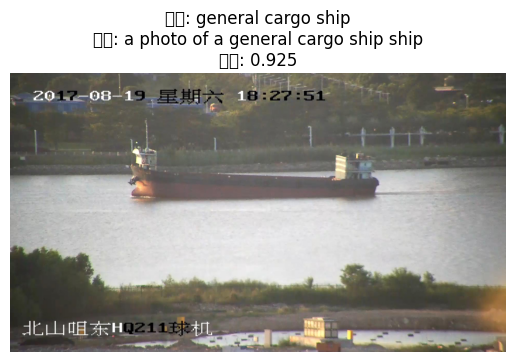

In [14]:
# 加载微调后的模型进行测试
from peft import PeftModel

base_model = CLIPModel.from_pretrained(MODEL_NAME)
model = PeftModel.from_pretrained(base_model, os.path.join(OUTPUT_DIR, "final_model"))
model.to(DEVICE)
model.eval()

# 随机选一张验证集图片
if val_loader:
    # 取一个 batch，注意 val_loader 返回三个值：images, candidate_texts_list, class_names
    sample_images, _, sample_class_names = next(iter(val_loader))
    idx = random.randint(0, len(sample_images)-1)
    test_image = sample_images[idx]
    true_class = sample_class_names[idx]           # 真实的类别名

    # 候选文本（可以用所有类别名生成）
    classes = val_dataset.class_names              # 从验证集获取类别列表
    candidate_texts = [f"a photo of a {cls} ship" for cls in classes]

    # 预处理图像和文本
    inputs = processor(text=candidate_texts, images=test_image, return_tensors="pt", padding=True).to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits_per_image[0]       # (num_candidates,)
        probs = logits.softmax(dim=-1).cpu().numpy()

    # 显示结果
    plt.imshow(test_image)
    plt.axis('off')
    plt.title(f"真值: {true_class}\n预测: {candidate_texts[probs.argmax()]}\n概率: {probs.max():.3f}")
    plt.show()
else:
    print("无验证集，跳过演示")

In [15]:
# 将输出目录打包，以便下载
!tar -czf clip_ship_output.tar.gz {OUTPUT_DIR}
print("打包完成，可下载 clip_ship_output.tar.gz")

打包完成，可下载 clip_ship_output.tar.gz
